# Metrics examples

This notebook shows what each of the metrics in [`icenet_mp.metrics`](../icenet_mp/metrics/) captures, using a small synthetic sea ice concentration field.

The metrics compared:

- **`IceNetAccuracyPerForecastDay`** — binary classification accuracy (ice / no ice) after thresholding concentration at 0.15.
- **`MAEPerForecastDay`** / **`RMSEPerForecastDay`** — pixel-wise concentration error, averaged (MAE) or root-mean-squared (RMSE).
- **`SeaIceExtentErrorPerForecastDay`** — signed difference between predicted and true total ice area (km²), summed over the whole field. Positive means the model over-predicts extent, negative means it under-predicts.

All four are computed per forecast lead time (day 0, 1, 2, ...) from `(batch, time, channel, height, width)` tensors.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from icenet_mp.metrics import (
    IceNetAccuracyPerForecastDay,
    MAEPerForecastDay,
    RMSEPerForecastDay,
    SeaIceExtentErrorPerForecastDay,
)

# Categorical colours, used in fixed order so a scenario always maps to the same colour
SCENARIO_COLORS = {
    "perfect": "#2a78d6",
    "overestimate extent": "#eb6834",
    "underestimate extent": "#1baf7a",
    "persistence": "#eda100",
    "shifted edge": "#4a3aa7",
    "noisy": "#e87ba4",
}
CONCENTRATION_CMAP = "Blues"

/var/folders/xr/xjkpw26d2gqgfzz06tkmfr5c0000gr/T/ipykernel_64840/2837458945.py:6: UserWarning: PYTORCH_ENABLE_MPS_FALLBACK was set after torch was imported. This means that it might not have any effect. If you have problems, please try setting this environment variable before importing torch.
  from icenet_mp.metrics import (


## Synthetic "truth"

The truth is a circular ice cap, centred in the domain, whose radius shrinks over the forecast (a stand-in for melt). Concentration transitions smoothly from 1 (ice) to 0 (open water) at the edge, as it would in real OSISAF-style data.

In [2]:
GRID_SIZE = 40
N_DAYS = 6
CENTER = (GRID_SIZE / 2, GRID_SIZE / 2)
RADIUS_START = 15.0
RADIUS_END = 8.0
EDGE_WIDTH = 2.0  # controls how sharp the ice edge is


def ice_field(
    grid_size: int, center: tuple[float, float], radius: float, edge_width: float = EDGE_WIDTH
) -> np.ndarray:
    """Smooth circular ice concentration field in [0, 1], centred at `center`."""
    yy, xx = np.indices((grid_size, grid_size))
    dist = np.sqrt((xx - center[0]) ** 2 + (yy - center[1]) ** 2)
    return 0.5 * (1 - np.tanh((dist - radius) / edge_width))


def to_tensor(field_stack: np.ndarray) -> torch.Tensor:
    """(time, height, width) array -> (batch=1, time, channel=1, height, width) tensor."""
    return torch.from_numpy(field_stack).float()[None, :, None, :, :]


truth_radii = np.linspace(RADIUS_START, RADIUS_END, N_DAYS)
truth = np.stack([ice_field(GRID_SIZE, CENTER, r) for r in truth_radii])
truth_t = to_tensor(truth)

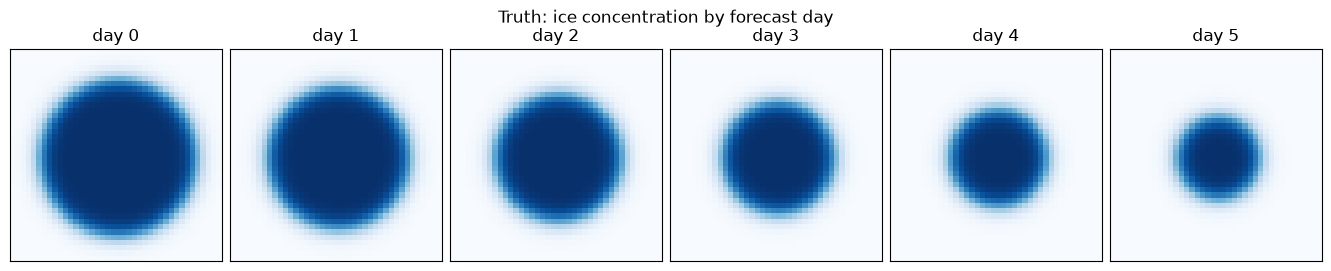

In [3]:
fig, axes = plt.subplots(1, N_DAYS, figsize=(2.2 * N_DAYS, 2.6), constrained_layout=True)
for day, ax in enumerate(axes):
    ax.imshow(truth[day], cmap=CONCENTRATION_CMAP, vmin=0, vmax=1)
    ax.set_title(f"day {day}")
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("Truth: ice concentration by forecast day")
plt.show()

## Prediction scenarios

Six "forecasts" of the same truth, each getting something different wrong:

- **perfect** — matches the truth exactly (sanity check, all metrics should read 0 / 100%).
- **overestimate extent** — melts too slowly, so too much ice is predicted (a common bias for models that under-predict melt).
- **underestimate extent** — melts too fast, so too little ice is predicted.
- **persistence** — the naive baseline: day-0 truth repeated for every lead time, i.e. "predict no change". Errors should grow with lead time.
- **shifted edge** — the *same* radius (and therefore total area) as the truth each day, but the ice cap is displaced sideways. Total extent is right, but the ice is in the wrong place.
- **noisy** — truth plus small random per-pixel noise, simulating sensor/model noise rather than a systematic error.

In [4]:
scenarios: dict[str, np.ndarray] = {}

scenarios["perfect"] = truth.copy()

slow_melt_radii = np.linspace(
    RADIUS_START, RADIUS_START - 0.5 * (RADIUS_START - RADIUS_END), N_DAYS
)
scenarios["overestimate extent"] = np.stack(
    [ice_field(GRID_SIZE, CENTER, r) for r in slow_melt_radii]
)

fast_melt_radii = np.linspace(RADIUS_START, RADIUS_END - 4.0, N_DAYS)
scenarios["underestimate extent"] = np.stack(
    [ice_field(GRID_SIZE, CENTER, r) for r in fast_melt_radii]
)

scenarios["persistence"] = np.stack([truth[0] for _ in range(N_DAYS)])

SHIFT = (6.0, 0.0)  # pixels; same radius as truth, just moved sideways
shifted_center = (CENTER[0] + SHIFT[0], CENTER[1] + SHIFT[1])
scenarios["shifted edge"] = np.stack(
    [ice_field(GRID_SIZE, shifted_center, r) for r in truth_radii]
)

rng = np.random.default_rng(0)
scenarios["noisy"] = np.clip(truth + rng.normal(0, 0.05, size=truth.shape), 0, 1)

scenario_tensors = {name: to_tensor(field) for name, field in scenarios.items()}

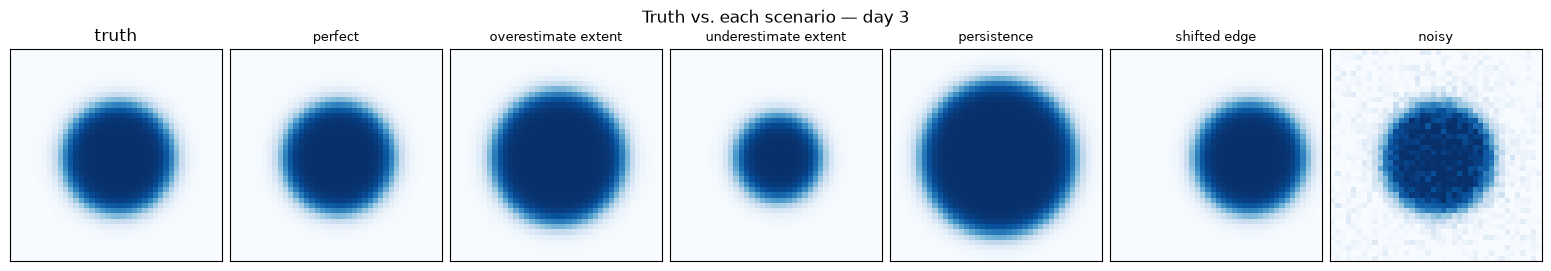

In [5]:
DAY_TO_SHOW = 3

n_scenarios = len(scenarios)
fig, axes = plt.subplots(1, n_scenarios + 1, figsize=(2.2 * (n_scenarios + 1), 2.6), constrained_layout=True)

axes[0].imshow(truth[DAY_TO_SHOW], cmap=CONCENTRATION_CMAP, vmin=0, vmax=1)
axes[0].set_title("truth")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

for ax, (name, field) in zip(axes[1:], scenarios.items(), strict=True):
    ax.imshow(field[DAY_TO_SHOW], cmap=CONCENTRATION_CMAP, vmin=0, vmax=1)
    ax.set_title(name, fontsize=9)

fig.suptitle(f"Truth vs. each scenario — day {DAY_TO_SHOW}")
plt.show()

## Computing the metrics

Each metric is a `torchmetrics.Metric`: create it, `update()` with predictions and target, then `compute()` to get one value per forecast day.

In [6]:
METRIC_CLASSES = {
    "accuracy (%)": IceNetAccuracyPerForecastDay,
    "mae": MAEPerForecastDay,
    "rmse": RMSEPerForecastDay,
    "sieerror (km²)": SeaIceExtentErrorPerForecastDay,
}

daily_results: dict[str, dict[str, np.ndarray]] = {}
for name, pred_t in scenario_tensors.items():
    daily_results[name] = {}
    for metric_name, metric_cls in METRIC_CLASSES.items():
        metric = metric_cls()
        metric.update(pred_t, truth_t)
        daily_results[name][metric_name] = metric.compute().numpy()

summary = pd.DataFrame(
    {
        metric_name: [daily_results[name][metric_name].mean() for name in scenarios]
        for metric_name in METRIC_CLASSES
    },
    index=list(scenarios.keys()),
)
summary.index.name = "scenario"
summary.round(3)

,accuracy (%),mae,rmse,sieerror (km²)
scenario,,,,
perfect,100.000000,0.000,0.000,0.000000
overestimate extent,91.083000,0.077,0.142,89166.664062
underestimate extent,92.000000,0.066,0.138,-80000.000000
persistence,80.708000,0.171,0.270,192916.671875
shifted edge,81.030998,0.167,0.309,-6562.500000
noisy,98.103996,0.028,0.040,3125.000000


## How each metric evolves with lead time

Each metric gets its own chart (never a shared/dual axis, since they're on different scales). Watch **persistence** grow steadily as the truth diverges from day 0, and compare **shifted edge** across charts — it's one of the worst scenarios for accuracy/RMSE but among the best for SIE error, since that metric only sees total area, not position.

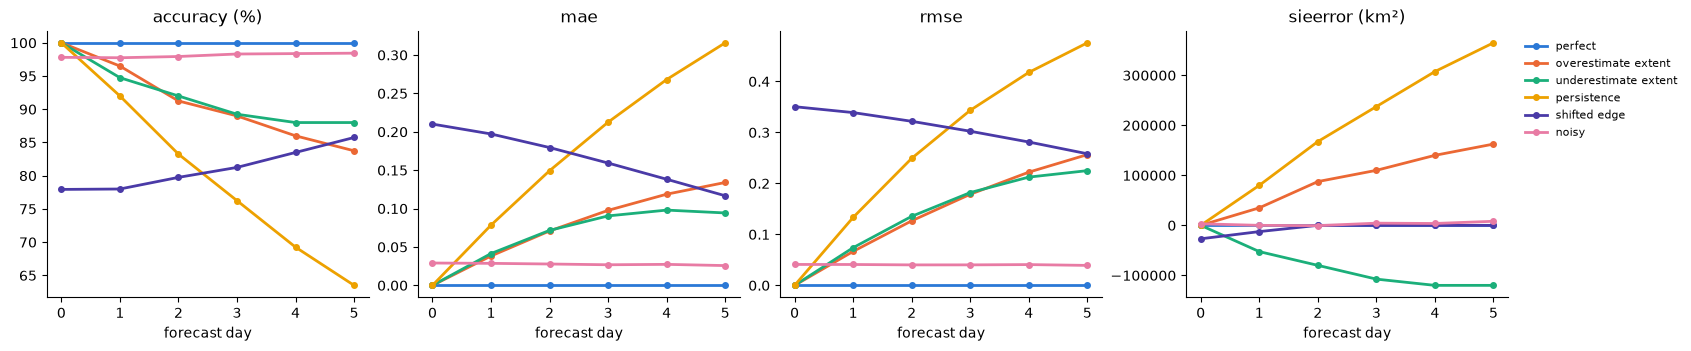

In [7]:
fig, axes = plt.subplots(1, len(METRIC_CLASSES), figsize=(4.2 * len(METRIC_CLASSES), 3.4), constrained_layout=True)

for ax, metric_name in zip(axes, METRIC_CLASSES, strict=True):
    for scenario_name in scenarios:
        ax.plot(
            range(N_DAYS),
            daily_results[scenario_name][metric_name],
            marker="o",
            markersize=4,
            linewidth=2,
            color=SCENARIO_COLORS[scenario_name],
            label=scenario_name,
        )
    ax.set_title(metric_name)
    ax.set_xlabel("forecast day")
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.show()

## Takeaways

Different metrics focus on different things:
- **`IceNetAccuracyPerForecastDay`** only cares which side of the 0.15 threshold each pixel lands on. It's insensitive to *how wrong* a prediction is within a class (the `noisy` scenario scores 98%+ despite non-zero MAE/RMSE), but it does penalise the `shifted edge` scenario heavily, since displaced ice puts pixels on the wrong side of the threshold.
- **`MAEPerForecastDay`** / **`RMSEPerForecastDay`** measure pixel-wise concentration error directly. RMSE weights large errors more than MAE, so it separates scenarios with a few big misses (`shifted edge`) from scenarios with many small ones (`noisy`) more sharply than MAE does.
- **`SeaIceExtentErrorPerForecastDay`** only looks at *total* ice area, summed over the whole field. This makes it the right metric for extent-focused validation (e.g. comparing against NSIDC-style sea ice extent), but it's blind to spatial displacement: `shifted edge` has the *same* area as the truth every day, so its SIE error is near zero even though it's one of the worst scenarios by every other metric. Because area errors partially cancel across the field, SIE error can also under-report scenarios with compensating over/under-estimates elsewhere in the domain. It should not be used by itself, but it is a useful when combined with accuracy to see areas of over / under prediction.

No single metric tells the whole story — a model that looks good on one can look bad on another. Report more than one, and pick the one that matches what actually matters for the use case (classification, magnitude, or aggregate extent).

## Masking land and inactive grid cells

Real SIC products are only meaningful over ocean — land cells are masked out. In this repo the convention is `1 = active ocean cell, 0 = land`, matching the `land_mask.npy` / `active_mask.npy` files built by `DataDownloader.generate_masks` and applied to model output by [`icenet_mp.models.common.mask.Mask`](../icenet_mp/models/common/mask.py) before the loss/metrics ever see it.

A model that isn't masked (the `Mask` layer was skipped, or masking was only applied at training time) can leak spurious ice concentration onto land. Below, a synthetic land mask is added to the domain, and a `land_leakage` prediction — otherwise as good as the `noisy` scenario above — shows how differently the four metrics react to that leakage, and to correcting for it.

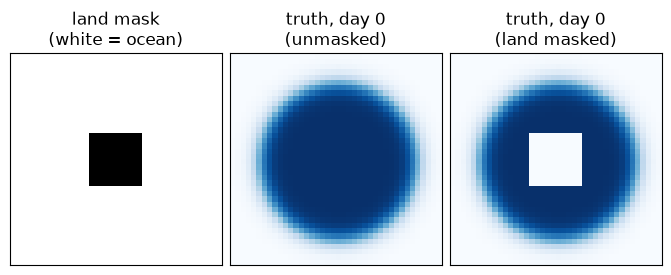

In [8]:
LAND_HALF_SIZE = 5  # a square island, centred in the domain; True = active ocean, False = land
cx, cy = int(CENTER[0]), int(CENTER[1])
LAND_MASK = np.ones((GRID_SIZE, GRID_SIZE), dtype=bool)
LAND_MASK[cy - LAND_HALF_SIZE : cy + LAND_HALF_SIZE, cx - LAND_HALF_SIZE : cx + LAND_HALF_SIZE] = False

truth_land_masked = truth * LAND_MASK[None, :, :]
truth_land_masked_t = to_tensor(truth_land_masked)

fig, axes = plt.subplots(1, 3, figsize=(6.6, 2.6), constrained_layout=True)
axes[0].imshow(LAND_MASK, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("land mask\n(white = ocean)")
axes[1].imshow(truth[0], cmap=CONCENTRATION_CMAP, vmin=0, vmax=1)
axes[1].set_title("truth, day 0\n(unmasked)")
axes[2].imshow(truth_land_masked[0], cmap=CONCENTRATION_CMAP, vmin=0, vmax=1)
axes[2].set_title("truth, day 0\n(land masked)")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

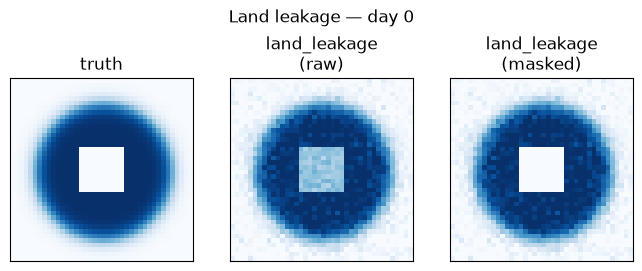

In [9]:
rng_leakage = np.random.default_rng(1)

# Ocean side: behaves like the `noisy` scenario (truth plus small noise)
ocean_noise = rng_leakage.normal(0, 0.05, size=truth.shape)
noisy_ocean = np.clip(truth_land_masked + ocean_noise, 0, 1) * LAND_MASK[None, :, :]

# Land side: as if the model never learned that land is always ice-free
leakage_noise = rng_leakage.normal(0, 0.05, size=truth.shape)
land_leakage = np.where(LAND_MASK[None, :, :], noisy_ocean, 0.4 + leakage_noise)
land_leakage = np.clip(land_leakage, 0, 1)
land_leakage_t = to_tensor(land_leakage)

zeroed_leakage = land_leakage * LAND_MASK[None, :, :]
zeroed_leakage_t = to_tensor(zeroed_leakage)

DAY_TO_SHOW_LAND = 0
fig, axes = plt.subplots(1, 3, figsize=(6.6, 2.6), constrained_layout=True)
axes[0].imshow(truth_land_masked[DAY_TO_SHOW_LAND], cmap=CONCENTRATION_CMAP, vmin=0, vmax=1)
axes[0].set_title("truth")
axes[1].imshow(land_leakage[DAY_TO_SHOW_LAND], cmap=CONCENTRATION_CMAP, vmin=0, vmax=1)
axes[1].set_title("land_leakage\n(raw)")
axes[2].imshow(zeroed_leakage[DAY_TO_SHOW_LAND], cmap=CONCENTRATION_CMAP, vmin=0, vmax=1)
axes[2].set_title("land_leakage\n(masked)")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle(f"Land leakage — day {DAY_TO_SHOW_LAND}")
plt.show()

### Comparing masking strategies

None of these metrics take a mask directly — only `IceNetAccuracyPerForecastDay` has a `sample_weight` argument, and it isn't currently passed anywhere in `BaseModel`'s train/val/test steps. So there are two ways to keep land out of the numbers:

- **zero pre-masking** — multiply predictions (and truth) by the land mask before calling `.update()`, exactly what `icenet_mp.models.common.mask.Mask` does to model output before it reaches the loss. Works for all four metrics, but land cells then count as trivially-correct "no ice" agreements, which inflates accuracy a little (more so the larger the land fraction).
- **`sample_weight`** — pass the mask into `IceNetAccuracyPerForecastDay.update(preds, target, sample_weight=...)` so land cells are excluded from both the numerator and denominator, rather than counted as free true negatives. Only available for this one metric — MAE, RMSE and SIE error have no equivalent, so they're identical to the "no masking" row below regardless.

In [10]:
land_weight_t = to_tensor(np.broadcast_to(LAND_MASK[None, :, :], truth.shape).astype(np.float32))


def compute_all(pred_t: torch.Tensor, sample_weight: torch.Tensor | None = None) -> dict[str, float]:
    """Compute the mean (over forecast days) of every metric against the land-masked truth."""
    accuracy_metric = IceNetAccuracyPerForecastDay()
    if sample_weight is not None:
        accuracy_metric.update(pred_t, truth_land_masked_t, sample_weight=sample_weight)
    else:
        accuracy_metric.update(pred_t, truth_land_masked_t)
    result = {"accuracy (%)": accuracy_metric.compute().mean().item()}
    for metric_name, metric_cls in list(METRIC_CLASSES.items())[1:]:
        metric = metric_cls()
        metric.update(pred_t, truth_land_masked_t)
        result[metric_name] = metric.compute().mean().item()
    return result


masking_comparison = pd.DataFrame(
    {
        "no masking": compute_all(land_leakage_t),
        "zeroed pre-masking": compute_all(zeroed_leakage_t),
        "sample_weight (accuracy only)": compute_all(land_leakage_t, sample_weight=land_weight_t),
    }
).T
masking_comparison.index.name = "masking strategy"
masking_comparison.round(3)

,accuracy (%),mae,rmse,sieerror (km²)
masking strategy,,,,
no masking,92.073,0.050,0.108,65729.164
zeroed pre-masking,98.323,0.025,0.039,3229.167
sample_weight (accuracy only),98.211,0.050,0.108,65729.164


### Takeaways

- Without any masking, land leakage alone drags every metric down — accuracy falls from ~98% to ~92%, MAE and RMSE roughly double, and SIE error jumps by more than 20× compared to the pure ocean-noise error underneath it. None of that reflects real forecast skill over the ocean; masking is what reveals it. The island sits inside the ice pack itself (not at the domain edge), so it punches a hole straight through the truth field, just as a real archipelago would.
- Zeroing predictions and truth over land before computing metrics recovers all four, but not exactly: land acts as "free" true negatives for accuracy, so the zeroed accuracy here (98.3%) reads *higher* than the properly excluded, `sample_weight`-based version (98.2%) for the same prediction — and that gap widens with the land fraction.
- `IceNetAccuracyPerForecastDay.sample_weight` is the only metric here with a real exclusion mechanism, and it isn't wired up anywhere in `BaseModel`'s train/val/test steps today. In practice, that means masking has to happen to predictions and targets *before* they reach these metrics — as `icenet_mp.models.common.mask.Mask` does — not inside the metrics themselves.

## Revisiting the six scenarios with the land mask applied

The land mask above was only ever tested against one dedicated `land_leakage` scenario. Here it's applied to the original six scenarios from the top of the notebook — zeroing both prediction and truth over the same masked island — to see whether it changes the "truth vs. each scenario" image grid and the metric summary table shown earlier.

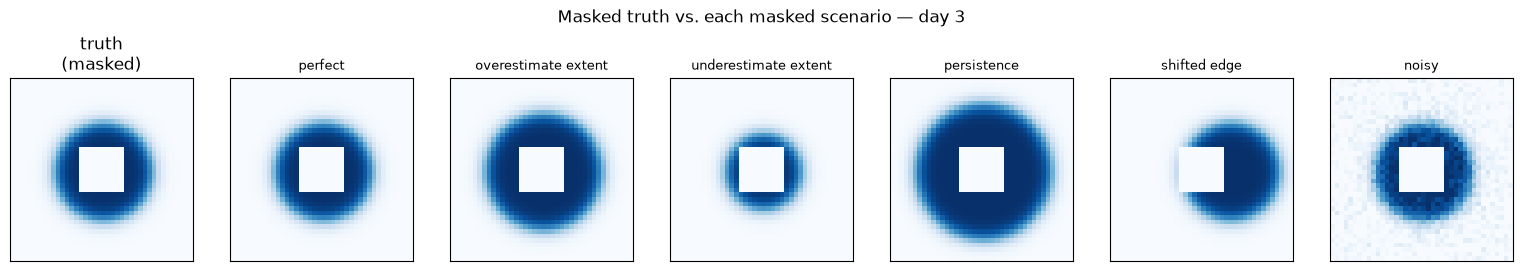

In [11]:
scenarios_masked = {name: field * LAND_MASK[None, :, :] for name, field in scenarios.items()}
scenario_tensors_masked = {name: to_tensor(field) for name, field in scenarios_masked.items()}

fig, axes = plt.subplots(1, n_scenarios + 1, figsize=(2.2 * (n_scenarios + 1), 2.6), constrained_layout=True)

axes[0].imshow(truth_land_masked[DAY_TO_SHOW], cmap=CONCENTRATION_CMAP, vmin=0, vmax=1)
axes[0].set_title("truth\n(masked)")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

for ax, (name, field) in zip(axes[1:], scenarios_masked.items(), strict=True):
    ax.imshow(field[DAY_TO_SHOW], cmap=CONCENTRATION_CMAP, vmin=0, vmax=1)
    ax.set_title(name, fontsize=9)

fig.suptitle(f"Masked truth vs. each masked scenario — day {DAY_TO_SHOW}")
plt.show()

In [12]:
daily_results_masked: dict[str, dict[str, np.ndarray]] = {}
for name, pred_t in scenario_tensors_masked.items():
    daily_results_masked[name] = {}
    for metric_name, metric_cls in METRIC_CLASSES.items():
        metric = metric_cls()
        metric.update(pred_t, truth_land_masked_t)
        daily_results_masked[name][metric_name] = metric.compute().numpy()

summary_masked = pd.DataFrame(
    {
        metric_name: [daily_results_masked[name][metric_name].mean() for name in scenarios]
        for metric_name in METRIC_CLASSES
    },
    index=list(scenarios.keys()),
)
summary_masked.index.name = "scenario"
summary_masked.round(3)

,accuracy (%),mae,rmse,sieerror (km²)
scenario,,,,
perfect,100.000000,0.000,0.000,0.000000
overestimate extent,91.083000,0.076,0.142,89166.664062
underestimate extent,92.094002,0.060,0.131,-79062.492188
persistence,80.708000,0.170,0.270,192916.671875
shifted edge,81.353996,0.158,0.299,-3333.333008
noisy,98.103996,0.026,0.039,3125.000000


Compare directly against the original (unmasked) `summary` table computed earlier, scenario by scenario:

In [13]:
summary_delta = (summary_masked - summary).round(3)
summary_delta

,accuracy (%),mae,rmse,sieerror (km²)
scenario,,,,
perfect,0.000,0.000,0.000,0.000000
overestimate extent,0.000,-0.000,-0.000,0.000000
underestimate extent,0.094,-0.006,-0.007,937.500000
persistence,0.000,-0.000,-0.000,0.000000
shifted edge,0.323,-0.009,-0.010,3229.166992
noisy,0.000,-0.001,-0.001,0.000000


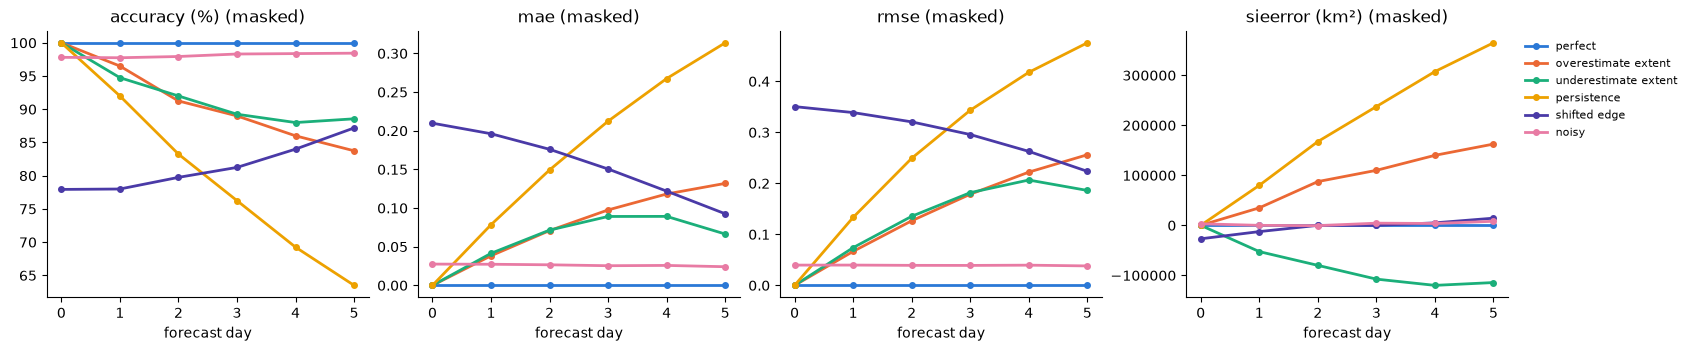

In [14]:
fig, axes = plt.subplots(1, len(METRIC_CLASSES), figsize=(4.2 * len(METRIC_CLASSES), 3.4), constrained_layout=True)

for ax, metric_name in zip(axes, METRIC_CLASSES, strict=True):
    for scenario_name in scenarios:
        ax.plot(
            range(N_DAYS),
            daily_results_masked[scenario_name][metric_name],
            marker="o",
            markersize=4,
            linewidth=2,
            color=SCENARIO_COLORS[scenario_name],
            label=scenario_name,
        )
    ax.set_title(f"{metric_name} (masked)")
    ax.set_xlabel("forecast day")
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.show()

### Takeaways

- For most scenarios, masking makes almost no difference (`perfect`, `overestimate extent`, `persistence`, `noisy` all shift by ≤0.001 on every metric). The masked island sits deep inside the ice pack for most of the forecast, so zeroing it out removes near-identical values from both prediction and truth — there's nothing left to disagree about.
- `underestimate extent` and `shifted edge` are the exceptions, and only by a little (accuracy +0.09pp and +0.32pp respectively; RMSE −0.007 and −0.010). Both have an ice edge that passes close to, or through, the masked island later in the forecast — `underestimate extent`'s remaining ice on the last day is only slightly larger than the island itself, and `shifted edge`'s displaced ice cap no longer sits fully concentric with it.
- The general rule: a mask only changes the comparison between forecasts when it overlaps the *disagreement* between prediction and truth — i.e. near a retreating or displaced ice edge — not just anywhere there happens to be land. A mask sitting well inside a region both sides agree on (solid ice, or open ocean) is metric-neutral by construction.

## Fractional Skill Score (FSS)

The metrics above compare concentration pixel-by-pixel or the whole field's total area. `FractionalSkillScorePerForecastDay` ([`icenet_mp.metrics.fss`](../icenet_mp/metrics/fss.py)) instead asks how well the *ice edge* is positioned, within some tolerance. Each field is reduced to a binary edge map (ice cells that border a non-ice cell), and the local fraction of edge cells inside a `neighborhood_size × neighborhood_size` window is compared between prediction and truth:

$$\mathrm{FSS} = 1 - \frac{\mathrm{MSE}}{\mathrm{MSE}_{\mathrm{ref}}}$$

FSS is 1 for a perfect match and ≤ 0 for no better than a worst-case reference. A small neighbourhood only forgives sub-pixel jitter in the edge; a large one forgives an edge displaced by many grid cells. This is why FSS is normally computed across a *range* of neighbourhood sizes — the size at which the curve crosses 0.5 is a rough measure of a forecast's "effective resolution" for edge position (Roberts and Lean, 2008; Melsom et al., 2019).

### What the binary edge map looks like

Before comparing FSS across scenarios, it helps to see exactly what `_binary_edge` extracts: for each field, threshold at 0.15 to get an ice/no-ice mask, then keep only the ice cells that border a non-ice cell. The red squares below mark those edge cells, overlaid on the day-3 concentration field already shown earlier — this is the *only* information FSS ever sees, everything else about the field is discarded.

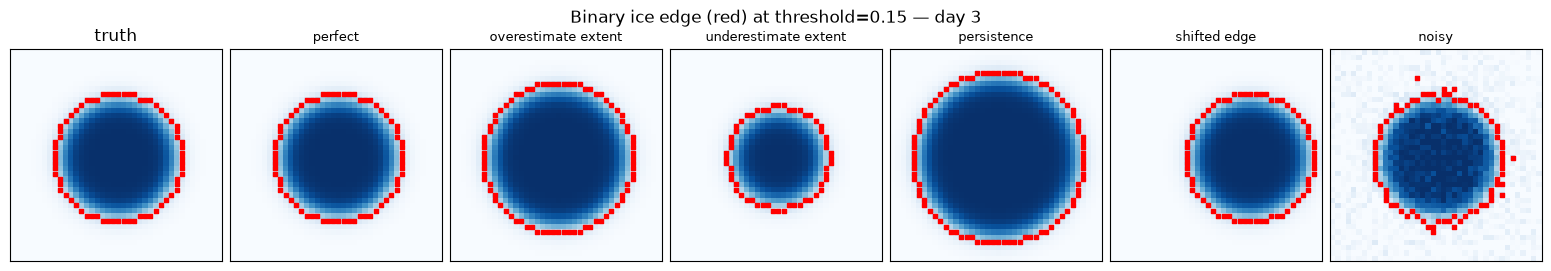

In [15]:
from icenet_mp.metrics.fss import SEA_ICE_THRESHOLD, FractionalSkillScorePerForecastDay


def binary_edge_map(field_day: np.ndarray) -> np.ndarray:
    """Boolean ice-edge map (ice cells bordering non-ice) for a single (H, W) field."""
    mask = torch.from_numpy(field_day > SEA_ICE_THRESHOLD)[None, :, :]
    return FractionalSkillScorePerForecastDay._binary_edge(mask)[0].numpy()


truth_edge = binary_edge_map(truth[DAY_TO_SHOW])
scenario_edges = {name: binary_edge_map(field[DAY_TO_SHOW]) for name, field in scenarios.items()}

fig, axes = plt.subplots(1, n_scenarios + 1, figsize=(2.2 * (n_scenarios + 1), 2.6), constrained_layout=True)


def overlay_edge(ax, field_day: np.ndarray, edge: np.ndarray) -> None:
    ax.imshow(field_day, cmap=CONCENTRATION_CMAP, vmin=0, vmax=1)
    ys, xs = np.nonzero(edge)
    ax.scatter(xs, ys, s=8, color="red", marker="s")


overlay_edge(axes[0], truth[DAY_TO_SHOW], truth_edge)
axes[0].set_title("truth")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

for ax, name in zip(axes[1:], scenarios, strict=True):
    overlay_edge(ax, scenarios[name][DAY_TO_SHOW], scenario_edges[name])
    ax.set_title(name, fontsize=9)

fig.suptitle(f"Binary ice edge (red) at threshold={SEA_ICE_THRESHOLD} — day {DAY_TO_SHOW}")
plt.show()

In [16]:
from icenet_mp.metrics import FractionalSkillScorePerForecastDay

FSS_NEIGHBORHOOD = 5  # pixels

fss_daily_results: dict[str, np.ndarray] = {}
for name, pred_t in scenario_tensors.items():
    metric = FractionalSkillScorePerForecastDay(neighborhood_size=FSS_NEIGHBORHOOD)
    metric.update(pred_t, truth_t)
    fss_daily_results[name] = metric.compute().numpy()

fss_summary = pd.DataFrame(
    {"fss": [fss_daily_results[name].mean() for name in scenarios]},
    index=list(scenarios.keys()),
)
fss_summary.index.name = "scenario"
fss_summary.round(3)

,fss
scenario,
perfect,1.000
overestimate extent,0.667
underestimate extent,0.611
persistence,0.404
shifted edge,0.337
noisy,0.965


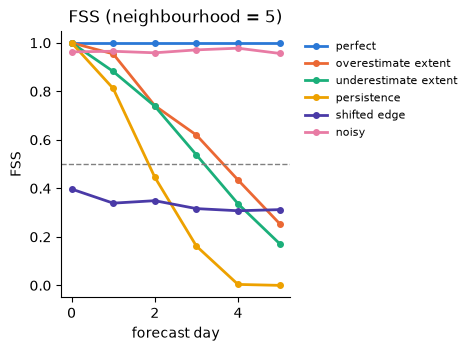

In [17]:
fig, ax = plt.subplots(figsize=(4.6, 3.4), constrained_layout=True)
for scenario_name in scenarios:
    ax.plot(
        range(N_DAYS),
        fss_daily_results[scenario_name],
        marker="o",
        markersize=4,
        linewidth=2,
        color=SCENARIO_COLORS[scenario_name],
        label=scenario_name,
    )
ax.axhline(0.5, color="grey", linestyle="--", linewidth=1)
ax.set_title(f"FSS (neighbourhood = {FSS_NEIGHBORHOOD})")
ax.set_xlabel("forecast day")
ax.set_ylabel("FSS")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.show()

### Effective resolution: scanning neighbourhood size

A single neighbourhood size only says whether the edge matches *at that tolerance*. Repeating the computation across a range of sizes and finding where FSS crosses 0.5 gives an "effective resolution" for each scenario — how far the predicted edge would need to be blurred/tolerated before it counts as a skilful match.

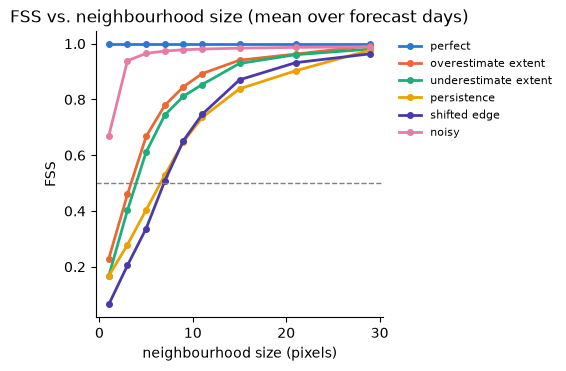

In [18]:
NEIGHBORHOOD_SIZES = [1, 3, 5, 7, 9, 11, 15, 21, 29]

fss_by_neighborhood: dict[str, list[float]] = {name: [] for name in scenarios}
for n in NEIGHBORHOOD_SIZES:
    for name, pred_t in scenario_tensors.items():
        metric = FractionalSkillScorePerForecastDay(neighborhood_size=n)
        metric.update(pred_t, truth_t)
        fss_by_neighborhood[name].append(metric.compute().mean().item())

fig, ax = plt.subplots(figsize=(5.2, 3.6), constrained_layout=True)
for scenario_name in scenarios:
    ax.plot(
        NEIGHBORHOOD_SIZES,
        fss_by_neighborhood[scenario_name],
        marker="o",
        markersize=4,
        linewidth=2,
        color=SCENARIO_COLORS[scenario_name],
        label=scenario_name,
    )
ax.axhline(0.5, color="grey", linestyle="--", linewidth=1)
ax.set_title("FSS vs. neighbourhood size (mean over forecast days)")
ax.set_xlabel("neighbourhood size (pixels)")
ax.set_ylabel("FSS")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.show()

### Takeaways

- **`perfect`** scores FSS = 1 at every neighbourhood size — there's no edge disagreement to tolerate.
- **`noisy`** is already above 0.5 at the smallest neighbourhood (1 pixel): the added noise perturbs the edge only slightly, so even the strictest tolerance counts it as skilful.
- **`overestimate extent`** and **`underestimate extent`** cross 0.5 quickly, by a neighbourhood of about 3–5 pixels — the edge is in roughly the right place, just slightly early or late.
- **`persistence`** and **`shifted edge`** are the slowest to recover: both sit well below 0.5 at small neighbourhoods (the frozen day-0 edge and the sideways-shifted edge are systematically, not just locally, wrong) and only cross 0.5 once the neighbourhood is large enough to swallow that systematic offset.

Unlike accuracy/MAE/RMSE, FSS says nothing about *how much* concentration is wrong at a pixel — only whether the ice edge is in approximately the right place, at whatever tolerance the neighbourhood size represents.

## Structural Similarity Index (SSIM)

MAE and RMSE compare every pixel independently, so two fields with the same total error score identically whether the difference is fine-grained noise or a coherent structural shift. `SSIMPerForecastDay` ([`icenet_mp.metrics.ssim`](../icenet_mp/metrics/ssim.py)) instead compares fields within a Gaussian-weighted window, combining local luminance, contrast, and structure (Wang et al., 2004):

$$\mathrm{SSIM} = \frac{(2\mu_a\mu_b + c_1)(2\sigma_{ab} + c_2)}{(\mu_a^2+\mu_b^2+c_1)(\sigma_a^2+\sigma_b^2+c_2)}$$

where $\mu$ and $\sigma^2$ are the local (Gaussian-filtered) mean and variance of each field, and $\sigma_{ab}$ their local covariance. SSIM is 1 for a perfect match and can go negative for anti-correlated fields. Unlike FSS, it doesn't threshold to a binary edge — it compares concentration directly.


In [19]:
from icenet_mp.metrics import SSIMPerForecastDay

ssim_daily_results: dict[str, np.ndarray] = {}
for name, pred_t in scenario_tensors.items():
    metric = SSIMPerForecastDay()
    metric.update(pred_t, truth_t)
    ssim_daily_results[name] = metric.compute().numpy()

ssim_summary = pd.DataFrame(
    {"ssim": [ssim_daily_results[name].mean() for name in scenarios]},
    index=list(scenarios.keys()),
)
ssim_summary.index.name = "scenario"
ssim_summary.round(3)


,ssim
scenario,
perfect,1.000
overestimate extent,0.712
underestimate extent,0.749
persistence,0.479
shifted edge,0.476
noisy,0.578


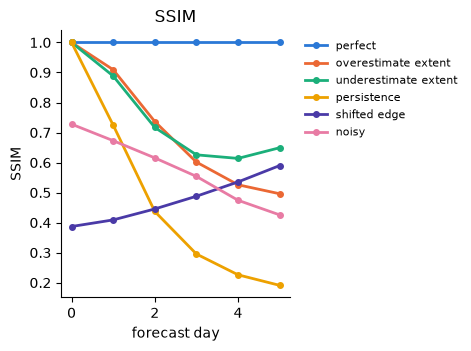

In [20]:
fig, ax = plt.subplots(figsize=(4.6, 3.4), constrained_layout=True)
for scenario_name in scenarios:
    ax.plot(
        range(N_DAYS),
        ssim_daily_results[scenario_name],
        marker="o",
        markersize=4,
        linewidth=2,
        color=SCENARIO_COLORS[scenario_name],
        label=scenario_name,
    )
ax.set_title("SSIM")
ax.set_xlabel("forecast day")
ax.set_ylabel("SSIM")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, fontsize=8)
plt.show()


### Takeaways

- **`noisy`** is the clearest contrast with the metrics above: it scores 98%+ on accuracy and has the lowest MAE/RMSE of any imperfect scenario, but its SSIM (0.58) is worse than both extent-bias scenarios. Independent per-pixel noise disrupts the *local* variance and covariance structure SSIM measures, even though the noise averages out to a small mean error.
- **`persistence`** and **`shifted edge`** score lowest overall (SSIM ≈ 0.48), consistent with FSS — both are systematically, not just locally, wrong, so no Gaussian window is large enough to reconcile prediction and truth within it.
- **`overestimate extent`** and **`underestimate extent`** sit in between (SSIM ≈ 0.71–0.75): the edge is in roughly the right place, so most windows away from the edge still match well.
- SSIM and FSS agree on the broad ranking (`shifted edge`/`persistence` worst, extent bias in between) but disagree sharply on `noisy`, which FSS rates as one of the *best* scenarios (FSS ≈ 0.97 at a 5-pixel neighbourhood) since edge position survives small per-pixel noise almost perfectly. SSIM is the one metric here that penalises `noisy` heavily — useful when small-scale texture, not just edge position or bulk error, matters for the downstream use case.
